In [154]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
import time

$X[k] = \sum_{n=0}^{N-1} x[n]e^{-i2\pi \frac{k}{N}n}$ - the DFT

$x[n] = \frac{1}{N}\sum_{k=0}^{N-1} X_{k}e^{\frac{i2\pi kn}{N}}$ - the inverse DFT

where
* N is the number of samples.
* n is the current sample.
* k is the current frequency.
* x[n] is the signal’s value at n.
* X[k] is the DFT at n.


k, n are indices, so should have same length. N is the number of datapoints. 

In [106]:
def func(x):
    return np.exp(-50*(x-0.5)**2)

def f_func(k):
    return np.sqrt(np.pi/50)*np.exp(-0.5*1j*k-(k**2/200))

Part b is saying to do the forward DFT for three values of N on the equation that I did analytically, then plot the results of these next to my analytical fourier transform.

When it says to invert k-space results, it means to do the inverse fourier transform.

In [107]:
def func_sampled(N):
    x = np.arange(N)/N #need to discretize the function
    
    return np.exp(-50*(x - 0.5)**2)

def DFT(inputfunc,N):
    X=np.zeros(N,dtype="complex") #keep the complex parts too
    for k in range(0,N): #by nature of python this should be N-1
        for n in range(0,N):
            X[k] += inputfunc[n] * (np.exp((-1j*2*np.pi*n*k)/N))
    return X

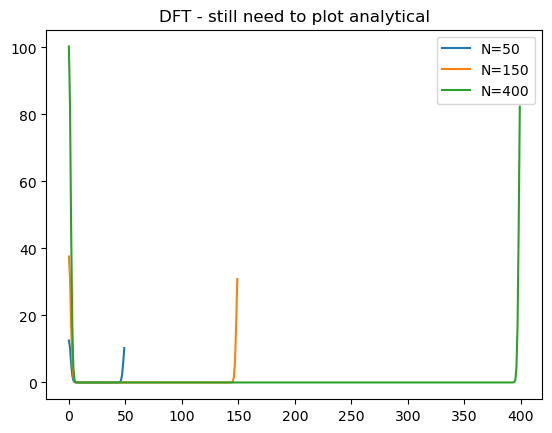

In [145]:
for N in [50, 150, 400]:
    x = func_sampled(N) 
    X = DFT(x, N) 
    k = np.arange(N) #vals to plot against (should be in k space)
    
    plt.plot(k, np.abs(X), label=f"N={N}")

plt.legend()
plt.title("DFT - still need to plot analytical")
plt.show()

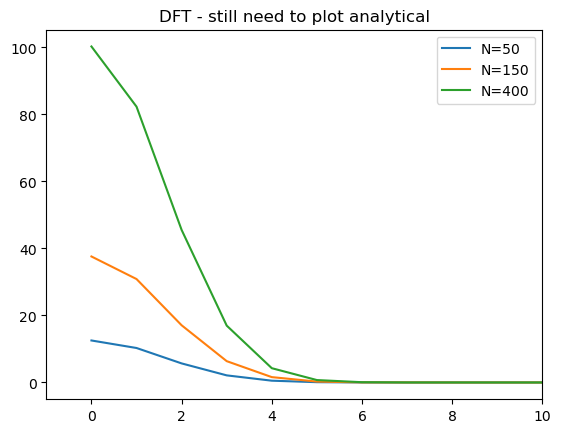

In [146]:
for N in [50, 150, 400]:
    x = func_sampled(N) 
    X = DFT(x, N)
    k = np.arange(N) #vals to plot against (should be in k space)
    
    plt.plot(k, np.abs(X), label=f"N={N}")

plt.legend()
plt.xlim(-1,10)
plt.title("DFT - still need to plot analytical")
plt.show()

In [147]:
#now I need to do the inverse of these:
def IDFT(inputfunc,N):
    x = np.zeros(N,dtype="complex") #keep the complex parts too
    for n in range(0,N): #by nature of python this should be N-1
        for k in range(0,N):
            x[n] += inputfunc[k] * (np.exp((1j*2*np.pi*n*k)/N))
    return x/N

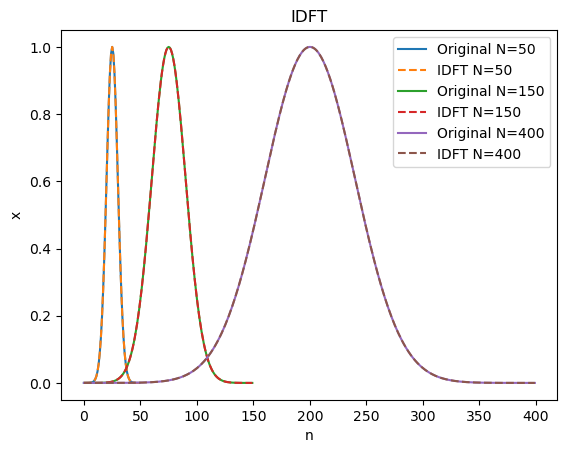

In [149]:
for N in [50, 150, 400]:
    x = func_sampled(N)
    X = DFT(x, N)
    x_idft = IDFT(X, N)

    n = np.arange(N)

    plt.plot(n, x, label=f"Original N={N}")
    plt.plot(n, x_idft, '--', label=f"IDFT N={N}")

plt.legend()
plt.title("IDFT")
plt.xlabel("n")
plt.ylabel("x")
plt.show()

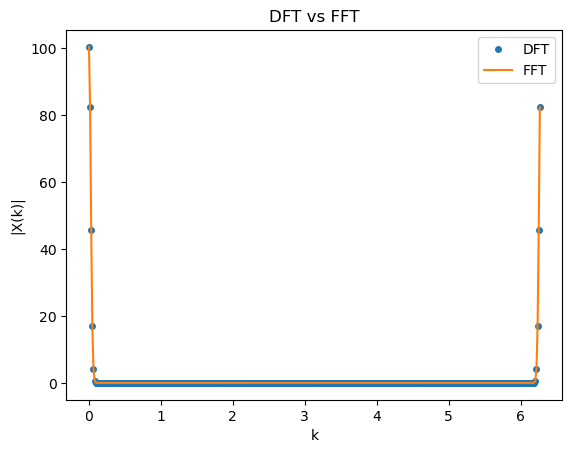

In [152]:
N = 400  
x = func_sampled(N) #discretizing function given

X_dft = DFT(x, N) #my DFT
X_fft = fft(x) #Scipy fft
k = 2*np.pi * np.arange(N)/N #k vals/frequency vals to plot against

plt.plot(k, np.abs(X_dft), 'o', label="DFT", markersize=4)
plt.plot(k, np.abs(X_fft), '-', label="FFT")
plt.xlabel("k")
plt.ylabel("|X(k)|")
plt.legend()
plt.title("DFT vs FFT")
plt.show()